In [4]:
"""BERT-based Named Entity Recognition on the PET dataset.

This notebook fine-tunes a pre-trained BERT model (`bert-base-uncased`) for
token classification on the 15 PET NER tags, then evaluates on the held-out test split.
"""
import random
import numpy as np
import torch
from datasets import load_dataset, Features, Sequence, Value, ClassLabel
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
)
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# ------------------------------------------------------------------ #
# 0. Reproducibility
# ------------------------------------------------------------------ #
SEED = 3407
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ------------------------------------------------------------------ #
# 1. Load the PET NER dataset (same schema as dataset.ipynb)
# ------------------------------------------------------------------ #
ner_tags_list = [ 
    "O", "B-Actor", "I-Actor", "B-Activity", "I-Activity", 
    "B-Activity Data", "I-Activity Data", "B-Further Specification", 
    "I-Further Specification", "B-XOR Gateway", "I-XOR Gateway", 
    "B-Condition Specification", "I-Condition Specification", 
    "B-AND Gateway", "I-AND Gateway"
]

features = Features({
    "document name": Value("string"),
    "sentence-ID": Value("int8"),
    "tokens": Sequence(Value("string")),
    "tokens-IDs": Sequence(Value("int8")),
    "ner-tags": Sequence(ClassLabel(names=ner_tags_list))
})

url_ner = "https://raw.githubusercontent.com/patriziobellan86/PETv1.1/master/PETv1.1-entities.jsonl"

ner_dataset = load_dataset("json", data_files={"test": url_ner}, features=features)
ner_split = ner_dataset["test"].train_test_split(test_size=0.2, seed=SEED)

print(f"Train examples: {len(ner_split['train'])}")
print(f"Test  examples: {len(ner_split['test'])}")
print(f"Number of NER tags: {len(ner_tags_list)}")

id2label = {i: tag for i, tag in enumerate(ner_tags_list)}
label2id = {tag: i for i, tag in enumerate(ner_tags_list)}

Train examples: 333
Test  examples: 84
Number of NER tags: 15


In [5]:
# ------------------------------------------------------------------ #
# 2. Tokenize the dataset with BERT's subword tokenizer
# ------------------------------------------------------------------ #
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_and_align_labels(examples):
    """
    Tokenize each sentence with BERT's subword tokenizer and align the
    word-level NER labels to subword tokens. Special tokens [CLS]/[SEP]
    are assigned -100 (ignored in loss). Subword tokens that are
    continuations of the same word are also assigned -100.
    """
    tokenized = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,   # input is already pre-tokenised
    )
    labels = []
    for i, label_ids in enumerate(examples["ner-tags"]):
        word_ids = tokenized.word_ids(batch_index=i)  # map subword → word index
        aligned = []
        previous_word_idx = None
        for word_idx in word_ids:
            if word_idx is None:
                # Special tokens [CLS], [SEP]
                aligned.append(-100)
            elif word_idx != previous_word_idx:
                # First subword of a word → use the word's label
                aligned.append(label_ids[word_idx])
            else:
                # Subsequent subword of the same word → ignore
                aligned.append(-100)
            previous_word_idx = word_idx
        labels.append(aligned)
    tokenized["labels"] = labels
    return tokenized

tokenized_train = ner_split["train"].map(tokenize_and_align_labels, batched=True)
tokenized_test  = ner_split["test"].map(tokenize_and_align_labels, batched=True)

print("Tokenisation complete.")

Tokenisation complete.


In [6]:
# ------------------------------------------------------------------ #
# 3. Initialise BERT for token classification
# ------------------------------------------------------------------ #
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(ner_tags_list),
    id2label=id2label,
    label2id=label2id,
)
print(f"Model has {model.num_parameters():,} parameters")
print(f"Device: {model.device}")

# ------------------------------------------------------------------ #
# 4. Fine-tune on the PET training split
# ------------------------------------------------------------------ #
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./bert-pet-ner",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    seed=SEED,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    processing_class=tokenizer,
    data_collator=data_collator,
)

trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly

Model has 108,903,183 parameters
Device: cpu


/Users/mac/Developer/VScode/uq-pet/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,No log,1.246275
2,No log,0.862474
3,1.238316,0.780300


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/mac/Developer/VScode/uq-pet/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=63, training_loss=1.1165173394339425, metrics={'train_runtime': 37.7214, 'train_samples_per_second': 26.484, 'train_steps_per_second': 1.67, 'total_flos': 19839960917910.0, 'train_loss': 1.1165173394339425, 'epoch': 3.0})

In [7]:
# ------------------------------------------------------------------ #
# 5. Evaluate: per-label precision / recall / F1
# ------------------------------------------------------------------ #
predictions, labels, _ = trainer.predict(tokenized_test)
preds = np.argmax(predictions, axis=2)

true_labels = []
pred_labels = []
for i in range(len(labels)):
    mask = labels[i] != -100           # filter out ignored positions
    true_labels.extend(labels[i][mask].tolist())
    pred_labels.extend(preds[i][mask].tolist())

report = classification_report(
    true_labels, pred_labels,
    labels=list(id2label.keys()),
    target_names=ner_tags_list,
    digits=4,
    zero_division=0,
)
print(report)

/Users/mac/Developer/VScode/uq-pet/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


                           precision    recall  f1-score   support

                        O     0.7550    0.8684    0.8077       699
                  B-Actor     0.9036    0.7812    0.8380        96
                  I-Actor     0.8359    0.8770    0.8560       122
               B-Activity     0.8707    0.9182    0.8938       110
               I-Activity     0.0000    0.0000    0.0000        16
          B-Activity Data     0.7732    0.7653    0.7692        98
          I-Activity Data     0.7175    0.7751    0.7452       249
  B-Further Specification     0.0000    0.0000    0.0000        15
  I-Further Specification     0.0000    0.0000    0.0000        58
            B-XOR Gateway     0.8333    0.6000    0.6977        25
            I-XOR Gateway     0.0000    0.0000    0.0000         7
B-Condition Specification     0.0000    0.0000    0.0000        17
I-Condition Specification     0.6632    0.6429    0.6528        98
            B-AND Gateway     0.0000    0.0000    0.0000     

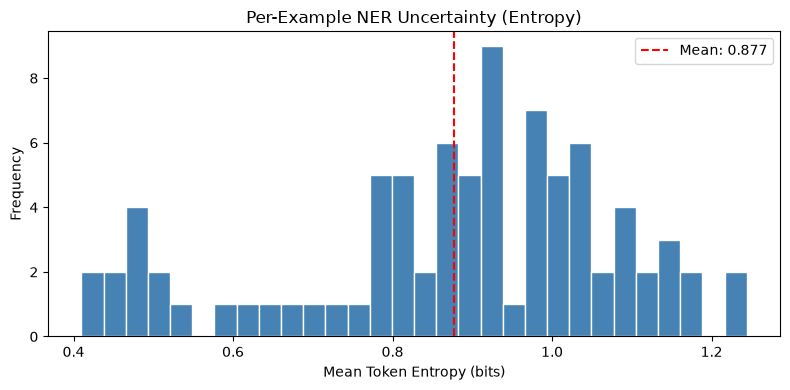


Top-5 MOST confident examples (lowest entropy):
  [66] entropy=0.4099  Three alternative process paths may be taken .
  [53] entropy=0.4337  By the way , that is the second step .
  [68] entropy=0.4484  The GO examines the application of the MPON .
  [44] entropy=0.4608  The ongoing repair consists of two activities , which are executed , in an arbitrary order .
  [73] entropy=0.4711  The MPOO confirms the order of the MPON and sends the master data .

Top-5 LEAST confident examples (highest entropy):
  [47] entropy=1.1541  Whenever the sales department receives an order , a new process instance is created .
  [24] entropy=1.1671  Either trouble report or the normal execution notification will be included in a status report and sent back to Service Management .
  [13] entropy=1.1807  The treasurer checks that all the receipts have been submitted and match the items on the list .
  [23] entropy=1.2326  This information is added to the assignment list .
  [48] entropy=1.2441  In the cas

In [8]:
# ------------------------------------------------------------------ #
# 6. Uncertainty Quantification — Prediction-level entropy
# ------------------------------------------------------------------ #
# For each token we compute the Shannon entropy over the 15-way softmax.
# This gives a per-token uncertainty score we can plot or aggregate.
probs = torch.softmax(torch.tensor(predictions), dim=-1).numpy()
entropy = -np.sum(probs * np.log(probs + 1e-12), axis=-1)

# Per-example mean token entropy
example_entropy = [
    entropy[i][labels[i] != -100].mean()
    for i in range(len(labels))
]

plt.figure(figsize=(8, 4))
plt.hist(example_entropy, bins=30, color="steelblue", edgecolor="white")
plt.xlabel("Mean Token Entropy (bits)")
plt.ylabel("Frequency")
plt.title("Per-Example NER Uncertainty (Entropy)")
plt.axvline(np.mean(example_entropy), color="red", linestyle="--",
            label=f"Mean: {np.mean(example_entropy):.3f}")
plt.legend()
plt.tight_layout()
plt.show()

# Print the 5 most & least confident examples
sorted_idx = np.argsort(example_entropy)
print("\nTop-5 MOST confident examples (lowest entropy):")
for idx in sorted_idx[:5]:
    sent = " ".join(ner_split["test"][int(idx)]["tokens"])
    print(f"  [{idx}] entropy={example_entropy[idx]:.4f}  {sent}")

print("\nTop-5 LEAST confident examples (highest entropy):")
for idx in sorted_idx[-5:]:
    sent = " ".join(ner_split["test"][int(idx)]["tokens"])
    print(f"  [{idx}] entropy={example_entropy[idx]:.4f}  {sent}")